# Breaking the Sparsity–Chaos Trade-off
## K-Sparse Chaotic Autoencoders - Complete Working Code

**Run all cells to reproduce results from the paper**

---

## 0. Setup & Imports

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Style
plt.style.use('default')
%matplotlib inline

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.16.2
GPU available: True


## 1. Data Generation - Logistic Map Images

**Logistic Map:** `x_{t+1} = r*x_t*(1-x_t)` with r=3.99 (chaotic regime)

Generated 5 test images
   Shape: (5, 28, 28, 1)
   Value range: [0.010, 0.998]
   Mean: 0.523, Std: 0.344


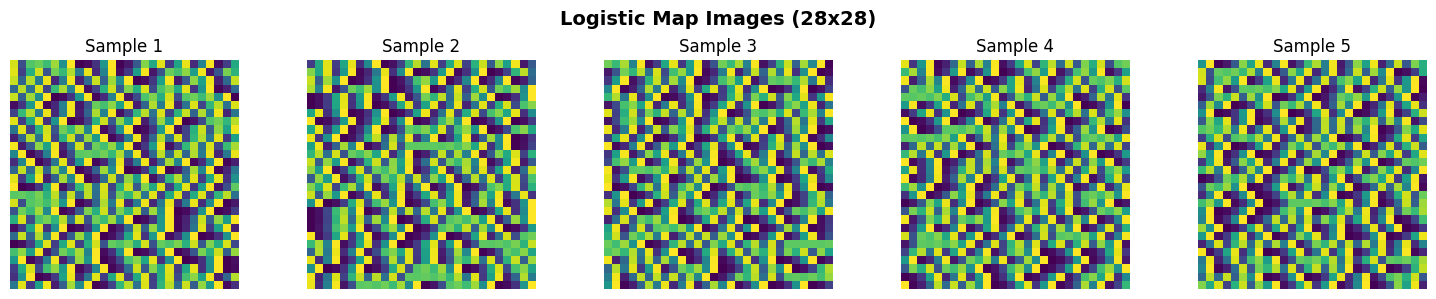

In [2]:
def logistic_map(x, r=3.99):
    """Logistic map iteration"""
    return r * x * (1 - x)

def generate_logistic_map_image(image_size=28, initial_value=0.4, r=3.99):
    """Generate single image from logistic map trajectory"""
    iterations = image_size * image_size
    x = initial_value
    seq = []
    for _ in range(iterations):
        x = logistic_map(x, r)
        seq.append(x)
    img = np.array(seq).reshape((image_size, image_size))
    return img

def generate_logistic_dataset(num_images, image_size=28, r=3.99, fixed_initial=False):
    """Generate dataset of logistic map images"""
    dataset = []
    for _ in range(num_images):
        init_val = 0.4 if fixed_initial else np.random.rand()
        img = generate_logistic_map_image(image_size=image_size, initial_value=init_val, r=r)
        dataset.append(img)
    return np.array(dataset)[..., np.newaxis].astype('float32')

# Test generation
test_data = generate_logistic_dataset(5)
print(f"Generated {len(test_data)} test images")
print(f"   Shape: {test_data.shape}")
print(f"   Value range: [{test_data.min():.3f}, {test_data.max():.3f}]")
print(f"   Mean: {test_data.mean():.3f}, Std: {test_data.std():.3f}")

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(test_data[i].squeeze(), cmap='viridis')
    ax.set_title(f'Sample {i+1}')
    ax.axis('off')
plt.suptitle('Logistic Map Images (28x28)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Custom Layers & Activations

### 2.1 Chaos Activation Function

`chaos_activation(x) = sin(8x) + 0.5*tanh(4x)`

**Properties:**
- High derivative (~8-10) vs ReLU (0 or 1)
- No fixed points
- Oscillatory + smooth components

2026-03-09 14:32:24.231294: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-03-09 14:32:24.231317: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-03-09 14:32:24.231337: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-03-09 14:32:24.231366: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-09 14:32:24.231380: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-09 14:32:24.243349: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


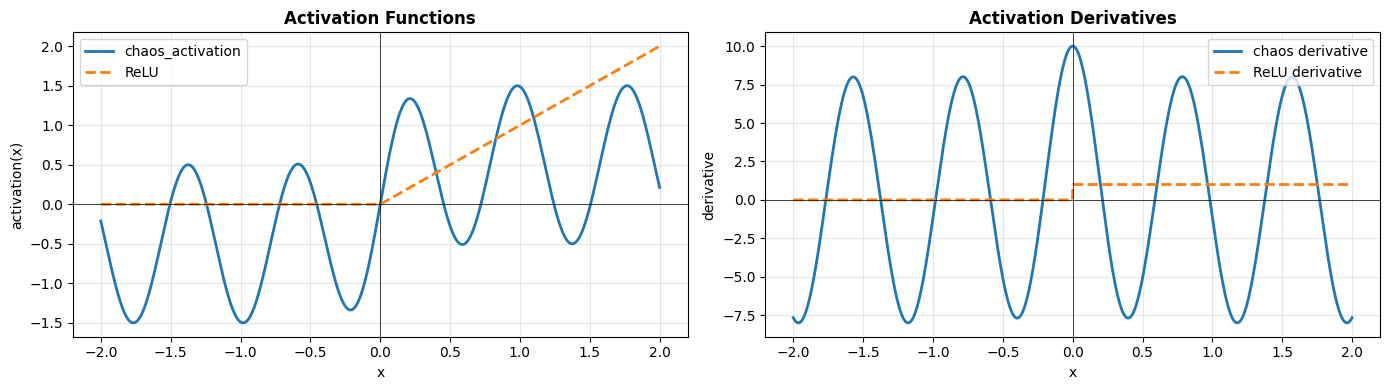

Chaos activation derivative range: [-8.0, 10.0]
   ReLU derivative: always 0 or 1


In [3]:
@tf.function
def chaos_activation(x):
    """Custom chaos-preserving activation"""
    return tf.sin(8.0 * x) + 0.5 * tf.tanh(4.0 * x)

# Visualize activation
x_vals = np.linspace(-2, 2, 1000)
y_chaos = [chaos_activation(x).numpy() for x in x_vals]
y_relu = np.maximum(0, x_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Activation
ax1.plot(x_vals, y_chaos, label='chaos_activation', linewidth=2)
ax1.plot(x_vals, y_relu, label='ReLU', linewidth=2, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('activation(x)')
ax1.set_title('Activation Functions', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Derivative
import tensorflow as tf
x_tensor = tf.constant(x_vals, dtype=tf.float32)
with tf.GradientTape() as tape:
    tape.watch(x_tensor)
    y_tensor = chaos_activation(x_tensor)
dy_chaos = tape.gradient(y_tensor, x_tensor).numpy()
dy_relu = np.where(x_vals > 0, 1, 0)

ax2.plot(x_vals, dy_chaos, label='chaos derivative', linewidth=2)
ax2.plot(x_vals, dy_relu, label='ReLU derivative', linewidth=2, linestyle='--')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('derivative')
ax2.set_title('Activation Derivatives', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Chaos activation derivative range: [{dy_chaos.min():.1f}, {dy_chaos.max():.1f}]")
print(f"   ReLU derivative: always 0 or 1")

### 2.2 Top-K Sparsity Layer

In [4]:
class KSparseLayer(layers.Layer):
    """Keep top-K activations, zero out the rest"""
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k
    
    def call(self, inputs, training=None):
        # Get top-K indices
        values, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        # Create mask
        latent_dim = tf.shape(inputs)[-1]
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype),
            axis=1
        )
        return inputs * mask
    
    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config

# Test K-Sparse Layer
test_input = tf.random.normal((2, 128))
ksparse = KSparseLayer(k=32)
output = ksparse(test_input)

sparsity = tf.reduce_mean(tf.cast(tf.abs(output) < 1e-6, tf.float32))
print(f"Input shape: {test_input.shape}")
print(f"   Output shape: {output.shape}")
print(f"   Sparsity: {sparsity.numpy():.1%} (expected 75.0%)")
print(f"   Active per sample: {tf.reduce_sum(tf.cast(tf.abs(output) > 1e-6, tf.int32), axis=-1).numpy()}")

Input shape: (2, 128)
   Output shape: (2, 128)
   Sparsity: 75.0% (expected 75.0%)
   Active per sample: [32 32]


### 2.3 Target Variance Regularizer

In [5]:
class TargetVarianceRegularizer(layers.Layer):
    """Encourage latent variance to match target"""
    def __init__(self, lambda_reg=0.01, target_variance=0.1, **kwargs):
        super().__init__(**kwargs)
        self.lambda_reg = lambda_reg
        self.target_variance = target_variance
    
    def call(self, inputs):
        current_variance = tf.math.reduce_variance(inputs, axis=0)
        mean_variance = tf.reduce_mean(current_variance)
        penalty = self.lambda_reg * tf.square(mean_variance - self.target_variance)
        self.add_loss(penalty)
        return inputs
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_reg": self.lambda_reg,
            "target_variance": self.target_variance
        })
        return config

print("Custom layers defined")

Custom layers defined


## 3. Architecture Definitions

### 3.1 V1: Broken (L1 + Activity Regularization)

In [6]:
def build_v1_broken(image_size=(28, 28), latent_dim=128):
    """V1: Standard sparse AE - FAILS on chaotic data"""
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    
    # Heavy regularization
    latent = layers.Dense(
        latent_dim,
        activation='relu',
        activity_regularizer=keras.regularizers.l1(1e-4),
        kernel_regularizer=keras.regularizers.l1(1e-4),
        name='latent'
    )(x)
    latent = layers.Dropout(0.2)(latent)
    
    encoder = keras.Model(input_img, latent, name='v1_broken_encoder')
    
    # Decoder
    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(x)
    
    autoencoder = keras.Model(input_img, decoded, name='v1_broken_ae')
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder

print("V1 (Broken) architecture defined")

V1 (Broken) architecture defined


### 3.2 V2: Simple Fix (L2 only)

In [7]:
def build_v2_simple(image_size=(28, 28), latent_dim=128):
    """V2: Remove L1, keep L2 - Works but low variance"""
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    
    # Only L2 regularization
    latent = layers.Dense(
        latent_dim,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='latent'
    )(x)
    
    encoder = keras.Model(input_img, latent, name='v2_simple_encoder')
    
    # Decoder
    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(x)
    
    autoencoder = keras.Model(input_img, decoded, name='v2_simple_ae')
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder

print("V2 (Simple Fix) architecture defined")

V2 (Simple Fix) architecture defined


### 3.3 V3: K-Sparse ReLU (Controlled Sparsity)

In [8]:
def build_v3_ksparse_relu(image_size=(28, 28), latent_dim=128, k_active=32):
    """V3: Top-K + ReLU - Controlled sparsity but still low variance"""
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    
    latent_raw = layers.Dense(latent_dim, activation='relu')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(latent_raw)
    
    encoder = keras.Model(input_img, latent, name='v3_ksparse_relu_encoder')
    
    # Decoder
    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(x)
    
    autoencoder = keras.Model(input_img, decoded, name='v3_ksparse_relu_ae')
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder

print("V3 (K-Sparse ReLU) architecture defined")

V3 (K-Sparse ReLU) architecture defined


### 3.4 V4: K-Sparse Chaos (FINAL SOLUTION)

In [9]:
def build_v4_ksparse_chaos(image_size=(28, 28), latent_dim=128, k_active=32):
    """V4: Chaos activation + Top-K + Target Variance - SOLVES THE PROBLEM!"""
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    
    # Encoder with chaos activation
    x = layers.Dense(256)(x)
    x = layers.Activation(chaos_activation)(x)
    
    latent_pre = layers.Dense(latent_dim, name='latent_pre')(x)
    latent_pre = layers.Activation(chaos_activation)(latent_pre)
    
    # Top-K selection
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(latent_pre)
    
    # Target variance regularizer
    latent = TargetVarianceRegularizer(
        lambda_reg=0.01,
        target_variance=0.1,
        name='variance_reg'
    )(latent)
    
    encoder = keras.Model(input_img, latent, name='v4_ksparse_chaos_encoder')
    
    # Decoder with chaos activation
    x = layers.Dense(256)(latent)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(x)
    
    autoencoder = keras.Model(input_img, decoded, name='v4_ksparse_chaos_ae')
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder

print("V4 (K-Sparse Chaos - FINAL) architecture defined")

V4 (K-Sparse Chaos - FINAL) architecture defined


## 4. Analysis Functions

In [10]:
def analyze_latent_statistics(encoder, images, zero_threshold=1e-6):
    """Comprehensive latent space analysis"""
    latents = encoder.predict(images, verbose=0)
    
    # Variance
    variance_per_dim = np.var(latents, axis=0)
    mean_variance = float(np.mean(variance_per_dim))
    
    # Dead neurons
    dead_mask = np.all(np.abs(latents) < zero_threshold, axis=0)
    dead_neurons = int(np.sum(dead_mask))
    total_neurons = latents.shape[1]
    
    # Sparsity
    zero_mask = np.abs(latents) < zero_threshold
    overall_sparsity = np.mean(zero_mask)
    
    # Active neurons
    active_per_sample = np.sum(~zero_mask, axis=1)
    mean_active = np.mean(active_per_sample)
    
    # Variance of active neurons only
    variance_active = []
    for dim in range(latents.shape[1]):
        dim_values = latents[:, dim]
        active_mask = ~zero_mask[:, dim]
        if np.sum(active_mask) > 1:
            active_values = dim_values[active_mask]
            variance_active.append(np.var(active_values))
    
    mean_variance_active = np.mean(variance_active) if variance_active else 0.0
    
    return {
        'variance_per_dim': variance_per_dim,
        'mean_variance': mean_variance,
        'dead_neurons': dead_neurons,
        'total_neurons': total_neurons,
        'dead_percentage': dead_neurons / total_neurons,
        'overall_sparsity': overall_sparsity,
        'mean_active_neurons': mean_active,
        'mean_variance_active': mean_variance_active,
        'latents': latents
    }

def print_analysis(name, stats):
    """Pretty print analysis results"""
    print(f"\n{'='*70}")
    print(f"Analysis: {name}")
    print(f"{'='*70}")
    print(f"Sparsity: {stats['overall_sparsity']:.1%}")
    print(f"Active neurons: {stats['mean_active_neurons']:.1f}/{stats['total_neurons']}")
    print(f"Dead neurons: {stats['dead_neurons']}/{stats['total_neurons']} ({stats['dead_percentage']:.1%})")
    print(f"Variance: {stats['mean_variance']:.6f}")
    print(f"Variance (active): {stats['mean_variance_active']:.6f}")

print("Analysis functions defined")

Analysis functions defined


## 5. EXPERIMENT: Train All 4 Versions

**This will take ~15-20 minutes on CPU, ~3-5 minutes on GPU**

In [11]:
# Generate training data
train_images = generate_logistic_dataset(2000, fixed_initial=False)
val_images = generate_logistic_dataset(500, fixed_initial=False)
test_images = generate_logistic_dataset(500, fixed_initial=False)
print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

# Training parameters
EPOCHS = 10
BATCH_SIZE = 64
LATENT_DIM = 128
K_ACTIVE = 32

results = {}

Train: 2000, Val: 500, Test: 500


In [12]:
# V1: Broken
ae_v1, enc_v1 = build_v1_broken(latent_dim=LATENT_DIM)
history_v1 = ae_v1.fit(
    train_images, train_images,
    validation_data=(val_images, val_images),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
stats_v1 = analyze_latent_statistics(enc_v1, test_images)
results['V1'] = {'model': ae_v1, 'encoder': enc_v1, 'stats': stats_v1, 'history': history_v1}
print_analysis("V1: BROKEN", stats_v1)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2.2508 - val_loss: 5.1172
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.3082 - val_loss: 4.8849
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.8595 - val_loss: 4.2346
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.2003 - val_loss: 3.6429
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.6071 - val_loss: 3.1525
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.1573 - val_loss: 2.8295
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8086 - val_loss: 2.5872
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.6070 - val_loss: 2.3928
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.3867 - val_loss: 2.1053
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.0941 - val_loss: 1.9712

Analysis: V1: BROKEN
Sparsity: 0.0%
Active neurons: 128.0/128
Dead neurons: 0/128 (0.0%)
Variance: 0.035461
Variance (active): 0.035461


In [13]:
# V2: Simple Fix
ae_v2, enc_v2 = build_v2_simple(latent_dim=LATENT_DIM)
history_v2 = ae_v2.fit(
    train_images, train_images,
    validation_data=(val_images, val_images),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
stats_v2 = analyze_latent_statistics(enc_v2, test_images)
results['V2'] = {'model': ae_v2, 'encoder': enc_v2, 'stats': stats_v2, 'history': history_v2}
print_analysis("V2: SIMPLE FIX", stats_v2)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1389 - val_loss: 0.1310
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1282 - val_loss: 0.1230
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1214 - val_loss: 0.1199
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1191 - val_loss: 0.1181
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1176 - val_loss: 0.1173
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1169 - val_loss: 0.1171
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1172 - val_loss: 0.1172
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1168 - val_loss: 0.1164
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1164 - val_loss: 0.1162
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1161 - val_loss: 0.1160

Analysis: V2: SIMPLE FIX
Sparsity: 0.0%
Active neurons: 128.0/128
Dead neurons: 0/128 (0.0%)
Variance: 0.001403
Variance (active): 0.001403


In [14]:
# V3: K-Sparse ReLU
ae_v3, enc_v3 = build_v3_ksparse_relu(latent_dim=LATENT_DIM, k_active=K_ACTIVE)
history_v3 = ae_v3.fit(
    train_images, train_images,
    validation_data=(val_images, val_images),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
stats_v3 = analyze_latent_statistics(enc_v3, test_images)
results['V3'] = {'model': ae_v3, 'encoder': enc_v3, 'stats': stats_v3, 'history': history_v3}
print_analysis("V3: K-SPARSE RELU", stats_v3)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1248 - val_loss: 0.1229
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1222 - val_loss: 0.1218
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1214 - val_loss: 0.1212
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1205 - val_loss: 0.1199
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1192 - val_loss: 0.1191
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1184 - val_loss: 0.1187
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1179 - val_loss: 0.1185
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1176 - val_loss: 0.1182
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1169 - val_loss: 0.1180
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1168 - val_loss: 0.1181

Analysis: V3: K-SPARSE RELU
Sparsity: 75.0%
Active neurons: 32.0/128
Dead neurons: 67/128 (52.3%)
Variance: 0.422926
Variance (active): 0.136624


In [15]:
# V4: K-Sparse Chaos
ae_v4, enc_v4 = build_v4_ksparse_chaos(latent_dim=LATENT_DIM, k_active=K_ACTIVE)
history_v4 = ae_v4.fit(
    train_images, train_images,
    validation_data=(val_images, val_images),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
stats_v4 = analyze_latent_statistics(enc_v4, test_images)
results['V4'] = {'model': ae_v4, 'encoder': enc_v4, 'stats': stats_v4, 'history': history_v4}
print_analysis("V4: K-SPARSE CHAOS (FINAL)", stats_v4)

print("\nALL VERSIONS TRAINED!")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1359 - val_loss: 0.1329
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1320 - val_loss: 0.1296
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1288 - val_loss: 0.1269
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1263 - val_loss: 0.1250
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1244 - val_loss: 0.1234
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1230 - val_loss: 0.1223
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1217 - val_loss: 0.1212
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1209 - val_loss: 0.1205
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1202 - val_loss: 0.1199
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1196 - val_loss: 0.1195

Analysis: V4: K-SPARSE CHAOS (FINAL)
Sparsity: 75.0%
Active neurons: 32.0/128
Dead neurons: 0/128 (0.0%)
Variance: 0.421023
Variance (active): 1.272

## 6. RESULTS: Evolution Comparison Table

In [16]:
# Comparison table
print("EVOLUTION COMPARISON TABLE")
print(f"{'Metric':<20} {'V1:Broken':<18} {'V2:Simple':<18} {'V3:KSparse':<18} {'V4:Chaos':<18}")
print("-"*90)

metrics = [
    ('Sparsity', lambda s: f"{s['overall_sparsity']:.1%}"),
    ('Active Neurons', lambda s: f"{s['mean_active_neurons']:.1f}"),
    ('Dead Neurons', lambda s: f"{s['dead_neurons']}"),
    ('Variance', lambda s: f"{s['mean_variance']:.6f}"),
    ('Val Loss', None)  # Special case
]

for metric_name, metric_fn in metrics:
    row = f"{metric_name:<20}"
    for version in ['V1', 'V2', 'V3', 'V4']:
        if metric_name == 'Val Loss':
            val = results[version]['history'].history['val_loss'][-1]
            row += f"{val:<18.6f}"
        else:
            val = metric_fn(results[version]['stats'])
            row += f"{val:<18}"
    print(row)


# Key achievement
v3_var = results['V3']['stats']['mean_variance']
v4_var = results['V4']['stats']['mean_variance']
improvement = v4_var / (v3_var + 1e-10)

print("\nKEY ACHIEVEMENT:")
print(f"V4 (Chaos) vs V3 (ReLU):")
print(f"  Variance improvement: {improvement:.0f}× ({v4_var:.6f} vs {v3_var:.6f})")
print(f"  Same sparsity: {results['V4']['stats']['overall_sparsity']:.1%}")
print(f"  Same active neurons: {results['V4']['stats']['mean_active_neurons']:.0f}")
print(f"  Dead neurons: 0% vs {results['V3']['stats']['dead_percentage']:.1%}")
print(f"\nFIRST ARCHITECTURE TO SOLVE THE SPARSITY-CHAOS TRADE-OFF!")

EVOLUTION COMPARISON TABLE
Metric               V1:Broken          V2:Simple          V3:KSparse         V4:Chaos          
------------------------------------------------------------------------------------------
Sparsity            0.0%              0.0%              75.0%             75.0%             
Active Neurons      128.0             128.0             32.0              32.0              
Dead Neurons        0                 0                 67                0                 
Variance            0.035461          0.001403          0.422926          0.421023          
Val Loss            1.971177          0.115988          0.118060          0.119501          

KEY ACHIEVEMENT:
V4 (Chaos) vs V3 (ReLU):
  Variance improvement: 1× (0.421023 vs 0.422926)
  Same sparsity: 75.0%
  Same active neurons: 32
  Dead neurons: 0% vs 52.3%

FIRST ARCHITECTURE TO SOLVE THE SPARSITY-CHAOS TRADE-OFF!


## 7. Visualizations

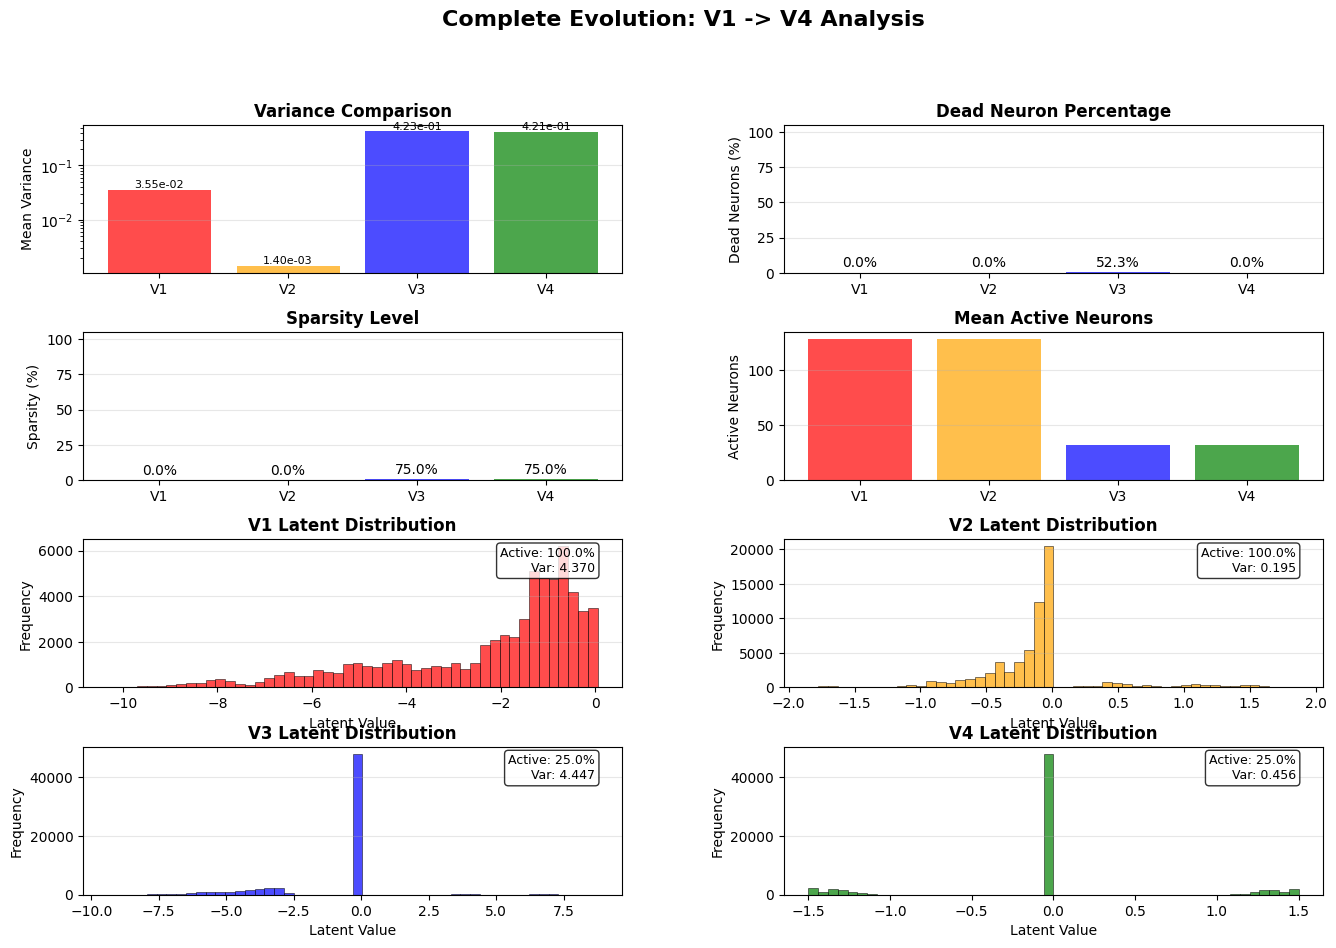

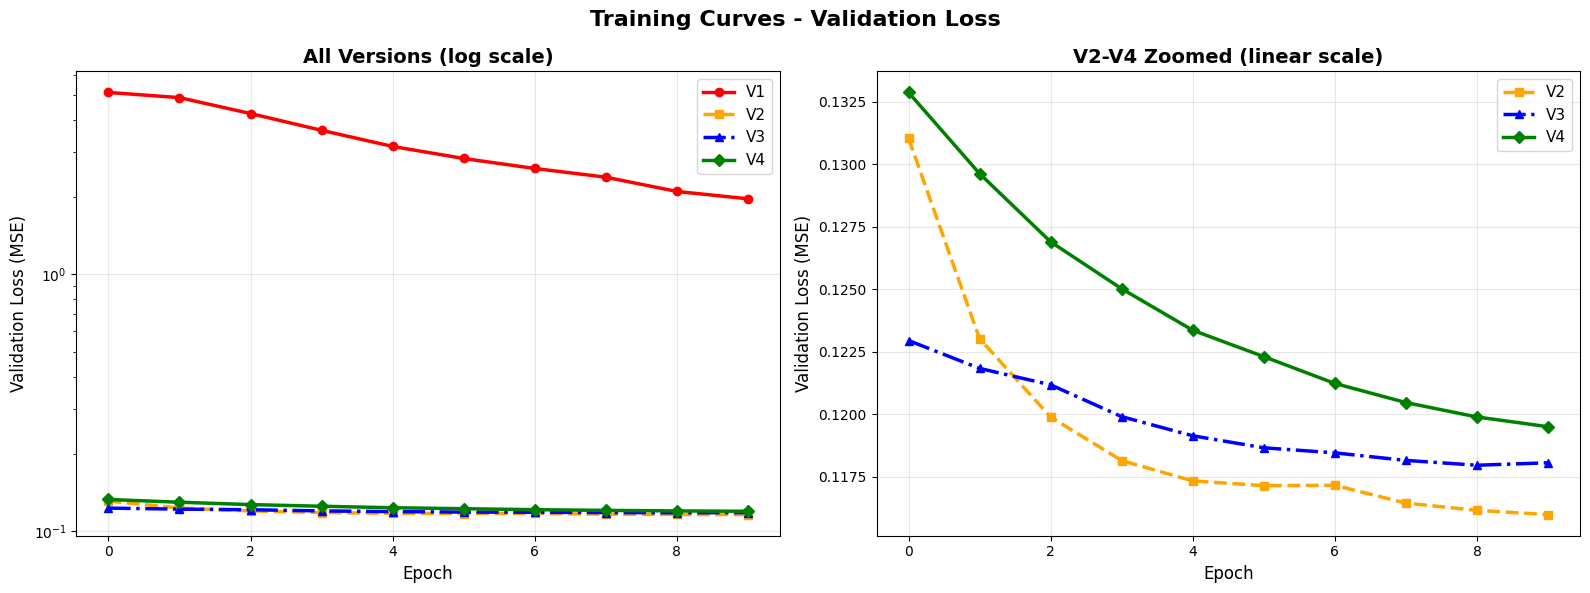

In [17]:
# Create comprehensive visualization - FIXED VERSION
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.3)

versions = ['V1', 'V2', 'V3', 'V4']
colors = ['red', 'orange', 'blue', 'green']

# Row 0: Variance and Dead neurons
ax1 = fig.add_subplot(gs[0, 0])
variances = [results[v]['stats']['mean_variance'] for v in versions]
bars = ax1.bar(versions, variances, color=colors, alpha=0.7)
ax1.set_ylabel('Mean Variance')
ax1.set_title('Variance Comparison', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{variances[i]:.2e}',
                ha='center', va='bottom', fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
dead = [results[v]['stats']['dead_percentage'] for v in versions]
bars = ax2.bar(versions, dead, color=colors, alpha=0.7)
ax2.set_ylabel('Dead Neurons (%)')
ax2.set_title('Dead Neuron Percentage', fontweight='bold')
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{dead[i]:.1%}',
            ha='center', va='bottom', fontsize=10)

# Row 1: Sparsity and Active neurons
ax3 = fig.add_subplot(gs[1, 0])
sparsity = [results[v]['stats']['overall_sparsity'] for v in versions]
bars = ax3.bar(versions, sparsity, color=colors, alpha=0.7)
ax3.set_ylabel('Sparsity (%)')
ax3.set_title('Sparsity Level', fontweight='bold')
ax3.set_ylim([0, 105])
ax3.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{sparsity[i]:.1%}',
            ha='center', va='bottom', fontsize=10)

ax4 = fig.add_subplot(gs[1, 1])
active = [results[v]['stats']['mean_active_neurons'] for v in versions]
bars = ax4.bar(versions, active, color=colors, alpha=0.7)
ax4.set_ylabel('Active Neurons')
ax4.set_title('Mean Active Neurons', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Row 2: Latent histograms (V1 and V2)
for idx in range(2):
    ax = fig.add_subplot(gs[2, idx])
    version = versions[idx]
    latents = results[version]['stats']['latents'].flatten()
    ax.hist(latents, bins=50, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Latent Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{version} Latent Distribution', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    active_pct = (np.abs(latents) > 1e-6).mean() * 100
    ax.text(0.95, 0.95, f'Active: {active_pct:.1f}%\nVar: {np.var(latents):.3f}',
           transform=ax.transAxes, ha='right', va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
           fontsize=9)

# Row 3: Latent histograms (V3 and V4)
for idx in range(2, 4):
    ax = fig.add_subplot(gs[3, idx - 2])
    version = versions[idx]
    latents = results[version]['stats']['latents'].flatten()
    ax.hist(latents, bins=50, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Latent Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{version} Latent Distribution', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    active_pct = (np.abs(latents) > 1e-6).mean() * 100
    ax.text(0.95, 0.95, f'Active: {active_pct:.1f}%\nVar: {np.var(latents):.3f}',
           transform=ax.transAxes, ha='right', va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
           fontsize=9)

plt.suptitle('Complete Evolution: V1 -> V4 Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('evolution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# Training curves - two subplots: full view + zoomed without V1 outlier
fig2, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(16, 6))
linestyles = ['-', '--', '-.', '-']
markers = ['o', 's', '^', 'D']

# Left: all versions with log scale to handle V1 outlier
for version, color, ls, mk in zip(versions, colors, linestyles, markers):
    losses = results[version]['history'].history['val_loss']
    ax_full.plot(losses, label=version, color=color, linewidth=2.5,
                 linestyle=ls, marker=mk, markersize=6)
ax_full.set_xlabel('Epoch', fontsize=12)
ax_full.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax_full.set_title('All Versions (log scale)', fontsize=14, fontweight='bold')
ax_full.set_yscale('log')
ax_full.legend(loc='upper right', fontsize=11)
ax_full.grid(True, alpha=0.3)

# Right: V2, V3, V4 zoomed in (linear scale)
for version, color, ls, mk in zip(versions[1:], colors[1:], linestyles[1:], markers[1:]):
    losses = results[version]['history'].history['val_loss']
    ax_zoom.plot(losses, label=version, color=color, linewidth=2.5,
                 linestyle=ls, marker=mk, markersize=6)
ax_zoom.set_xlabel('Epoch', fontsize=12)
ax_zoom.set_ylabel('Validation Loss (MSE)', fontsize=12)
ax_zoom.set_title('V2-V4 Zoomed (linear scale)', fontsize=14, fontweight='bold')
ax_zoom.legend(loc='upper right', fontsize=11)
ax_zoom.grid(True, alpha=0.3)

plt.suptitle('Training Curves - Validation Loss', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Reconstruction Quality Check

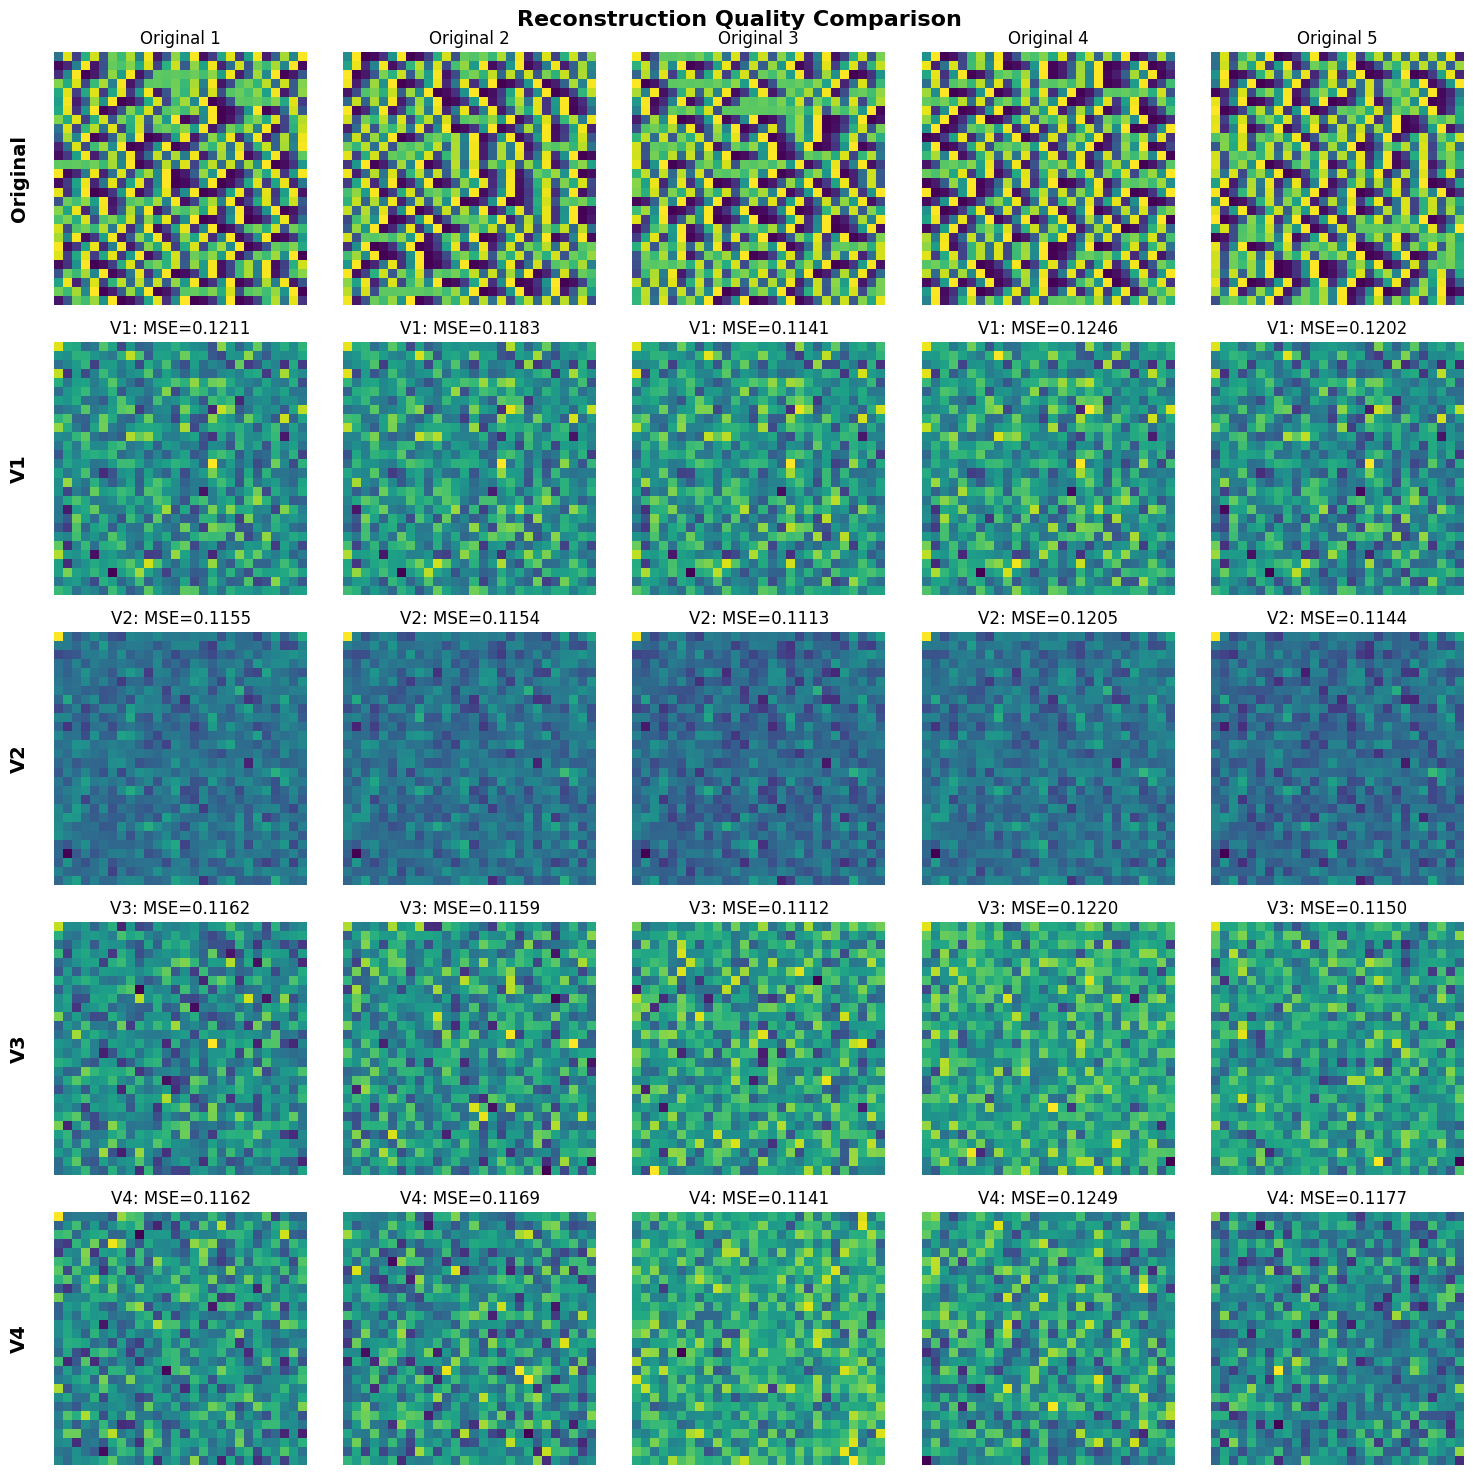

Reconstruction quality visualization saved


In [18]:
# Visualize reconstructions
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

# Original images
sample_images = test_images[:5]
for i in range(5):
    axes[0, i].imshow(sample_images[i].squeeze(), cmap='viridis')
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')

# Reconstructions for each version
for row, version in enumerate(versions, start=1):
    model = results[version]['model']
    reconstructed = model.predict(sample_images, verbose=0)
    
    for col in range(5):
        axes[row, col].imshow(reconstructed[col].squeeze(), cmap='viridis')
        # Calculate MSE for this sample
        mse = np.mean((sample_images[col] - reconstructed[col])**2)
        axes[row, col].set_title(f'{version}: MSE={mse:.4f}')
        axes[row, col].axis('off')

# Add row labels
for row, label in enumerate(['Original', 'V1', 'V2', 'V3', 'V4']):
    axes[row, 0].text(-0.1, 0.5, label, transform=axes[row, 0].transAxes,
                     fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)

plt.suptitle('Reconstruction Quality Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('reconstruction_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print("Reconstruction quality visualization saved")

## 9. Summary

V4 (K-Sparse Chaos) demonstrates that combining Top-K selection with sin(8x)+0.5*tanh(4x) activation eliminates dead neurons while maintaining controlled sparsity and high latent variance on chaotic data.